In [17]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 50px 40px; border-radius: 12px; margin-bottom: 30px;">
  <h1 style="color: #e94560; font-size: 2.8em; margin: 0 0 10px 0; font-family: 'Segoe UI', sans-serif;">2nd Order HBM Adaptation</h1>
  <h3 style="color: #a8b2d8; font-weight: 300; margin: 0 0 20px 0; font-family: 'Segoe UI', sans-serif;">From First-Order State Space to Second-Order Mechanical Formulation</h3>
  <hr style="border-color: #e94560; margin: 0 0 15px 0;">
  <div style="display:flex; gap:30px; color:#8892b0;">
    <span>📁 <b style="color:#a8b2d8">4</b> source files changed</span>
    <span>✚ <b style="color:#81c784">845</b> insertions</span>
    <span>✖ <b style="color:#e94560">67</b> deletions</span>
    <span>🔗 commits <code style="color:#e94560">ff2dc47</code> → <code style="color:#e94560">9978074</code></span>
  </div>
</div>

---
## 1 · Problem Formulation

### 1st Order — State Space

State vector $\mathbf{z} = [u,\, v]^\top$ where $v = \dot{u}$, dimension $= n_\mathrm{dof} \times 2$

$$\Large \omega\,\mathbf{z}' = \mathbf{A}\mathbf{z} + \mathbf{f}^\mathrm{nl}(\mathbf{z},\tau) + \mathbf{f}^\mathrm{ext}(\tau)$$

### 2nd Order — Mechanical Form

State $\mathbf{q}$ (displacement only), dimension $= n_\mathrm{dof}$ — **half the unknowns**

$$\Large \mathbf{M}\ddot{\mathbf{q}} + \mathbf{C}\dot{\mathbf{q}} + \mathbf{K}\mathbf{q} + \mathbf{f}^\mathrm{nl}(\mathbf{q},\dot{\mathbf{q}}) = \mathbf{f}^\mathrm{ext}(\tau)$$

In adimensional time $\tau = \omega t$, velocity becomes $\dot{\mathbf{q}} = \omega\mathbf{q}'$. This introduces $\omega$ into the nonlinear term — the central challenge of the 2nd order formulation.

---
## 2 · `dynamical_system.py` — New `SecondOrderODE` Base Class

Physical matrices **M**, **C**, **K** replace the single `linear_coefficient` matrix. The nonlinear interface gains a second Jacobian w.r.t. velocity.

<table style="width:100%; border-collapse:collapse; margin-top:12px;">
  <tr style="background:#16213e;">
    <th style="padding:10px; color:#4fc3f7; border-bottom:2px solid #4fc3f7; text-align:left;">FirstOrderODE</th>
    <th style="padding:10px; color:#81c784; border-bottom:2px solid #81c784; text-align:left;">SecondOrderODE (new)</th>
  </tr>
  <tr style="background:#0d1117;">
    <td style="padding:9px; color:#ccc;"><code>linear_coefficient</code> &nbsp;(matrix <b>A</b>)</td>
    <td style="padding:9px; color:#ccc;"><code>mass_matrix</code>, <code>damping_matrix</code>, <code>stiffness_matrix</code></td>
  </tr>
  <tr style="background:#161b22;">
    <td style="padding:9px; color:#ccc;"><code>nonlinear_term(state, tau)</code></td>
    <td style="padding:9px; color:#ccc;"><code>nonlinear_term(q, q_dot, tau)</code></td>
  </tr>
  <tr style="background:#0d1117;">
    <td style="padding:9px; color:#ccc;"><code>jacobian_nonlinear_term(state, tau)</code></td>
    <td style="padding:9px; color:#ccc;"><code>jacobian_nonlinear_term(q, q_dot, tau)</code></td>
  </tr>
  <tr style="background:#161b22;">
    <td style="padding:9px; color:#888;"><em>—</em></td>
    <td style="padding:9px; color:#ccc;"><code>jacobian_nonlinear_term_qdot(q, q_dot, tau)</code> &nbsp;<span style="color:#ffb74d">(new)</span></td>
  </tr>
</table>

```python
class SecondOrderODE:
    def __init__(self):
        self.mass_matrix:       np.ndarray = np.eye(1)
        self.damping_matrix:    np.ndarray = np.zeros((1, 1))
        self.stiffness_matrix:  np.ndarray = np.eye(1)
        self.dimension:         int = 1
        self.polynomial_degree: int = 3

    def external_term(self, tau):                          ...  # fext(tau)
    def nonlinear_term(self, q, q_dot, tau):               ...  # fnl(q, qdot)
    def jacobian_nonlinear_term(self, q, q_dot, tau):      ...  # ∂fnl/∂q
    def jacobian_nonlinear_term_qdot(self, q, q_dot, tau): ...  # ∂fnl/∂qdot
```

---
## 3 · `frequency_domain.py` — `FrequencyDomainSecondOrderODE_Real`

### 3.1 Residue

For each harmonic $n$:

$$\Large \mathbf{R}_n = \bigl(-\omega^2 n^2\mathbf{M} + j\omega n\mathbf{C} + \mathbf{K}\bigr)\mathbf{Q}_n + \mathbf{F}^\mathrm{nl}_n - \mathbf{F}^\mathrm{ext}_n = 0$$

The velocity time series for the AFT evaluation:

$$\Large \dot{\mathbf{q}}(\tau_k) = \omega \cdot \mathrm{IDFT}\{jn\,\mathbf{Q}_n\}_k$$

```python
def compute_nonlinear_term(self, x: FourierOmegaPoint) -> Fourier_Real:
    state, ome = x.fourier, x.omega
    Fourier_Real.compute_time_series(state)                                     # q(τ_k)
    qdot_fourier = Fourier_Real(
        1j * ome * einsum('i,ijk->ijk', Fourier.harmonics, state.coefficients)  # jωn·Q_n
    )
    Fourier_Real.compute_time_series(qdot_fourier)                              # qdot(τ_k)
    fnl_ts = self.ode.nonlinear_term(
        state.time_series, qdot_fourier.time_series, Fourier.adimensional_time_samples
    )
    return Fourier_Real.new_from_time_series(fnl_ts)
```

### 3.2 Jacobian of the Residue

Chain rule for $\mathbf{f}^\mathrm{nl}(\mathbf{q},\, \omega\mathbf{q}')$:

$$\Large \frac{\partial \mathbf{F}^\mathrm{nl}}{\partial \mathbf{Q}} = \underbrace{\frac{\partial \mathbf{f}^\mathrm{nl}}{\partial \mathbf{q}}}_{\mathbf{J}_q} + \underbrace{\frac{\partial \mathbf{f}^\mathrm{nl}}{\partial \dot{\mathbf{q}}}}_{\mathbf{J}_{\dot{q}}} \cdot j\omega n$$

Multiplying $\mathbf{J}_{\dot{q}}$ by $j\omega n$ in the RI block structure ($j$ swaps and negates real/imaginary blocks):

```python
col_scale = kron(diag(ome * Fourier.harmonics), eye(self.ode.dimension))  # ω·n

JacobianFourier_Real(
    RR = jac_q.RR + jac_qdot.RI @ col_scale,
    RI = jac_q.RI - jac_qdot.RR @ col_scale,
    IR = jac_q.IR + jac_qdot.II @ col_scale,
    II = jac_q.II - jac_qdot.IR @ col_scale
)
```

### 3.3 Derivative w.r.t. $\omega$

$$\Large \frac{d\mathbf{R}}{d\omega} = \underbrace{\bigl(-2\omega n^2 \mathbf{M} + jn\mathbf{C}\bigr)\mathbf{Q}_n}_{\text{linear}} + \underbrace{\mathrm{DFT}\!\left\{\frac{\partial \mathbf{f}^\mathrm{nl}}{\partial \dot{\mathbf{q}}} \cdot \mathbf{q}'\right\}}_{\text{nonlinear — was missing}}$$

Follows from $\partial\dot{\mathbf{q}}/\partial\omega = \mathbf{q}'$ (since $\dot{\mathbf{q}} = \omega\mathbf{q}'$).

<div style="background:#2d1f00; border:1px solid #ffb74d; border-radius:8px; padding:12px 18px; margin:14px 0;">
<b style="color:#ffb74d">⚠ Why the missing term caused divergence at $\omega \approx 1.6$:</b><br><br>
<span style="color:#ccc">For $f^\mathrm{nl} = \beta q^3 + \alpha\dot{q}q^2$, near resonance with amplitude $\sim 100$:</span><br><br>
<span style="color:#ffb74d">missing: &nbsp;</span><span style="color:#ccc">$\alpha q^2 q' \approx 0.1 \times 10^4 \times 10^2 = 10^5$</span><br>
<span style="color:#4fc3f7">linear: &nbsp;&nbsp;</span><span style="color:#ccc">$(-2\omega n^2 M + jnC)\,Q \approx 200$</span><br><br>
<span style="color:#ccc">The predictor direction was completely wrong → corrector diverged.</span>
</div>

```python
def compute_derivative_wrt_omega_RI(self, x: FourierOmegaPoint) -> array:
    state, ome, n = x.fourier, x.omega, Fourier.harmonics
    derivative_linear = (
          einsum('i,ijk->ijk', -2*ome*n**2, self.ode.mass_matrix    @ state.coefficients)
        + einsum('i,ijk->ijk',      1j*n,   self.ode.damping_matrix @ state.coefficients)
    )
    Fourier_Real.compute_time_series(state)
    q = state.time_series
    q_prime_fourier = Fourier_Real(einsum('i,ijk->ijk', 1j*n, state.coefficients))
    Fourier_Real.compute_time_series(q_prime_fourier)
    q_prime = q_prime_fourier.time_series
    dfnldqdot = self.ode.jacobian_nonlinear_term_qdot(
        q, q_prime * ome, Fourier.adimensional_time_samples
    )
    derivative_nonlinear = Fourier_Real.new_from_time_series(dfnldqdot @ q_prime)
    derivative_wrt_omega  = derivative_linear + derivative_nonlinear.coefficients
    ...
```

---
## 4 · `core.py` — Extended `HarmonicBalanceMethod`

```python
# Before
def __init__(self, first_order_ode: FirstOrderODE, harmonics, ...):
    self.freq_domain_ode = FrequencyDomainFirstOrderODE_Real(first_order_ode)

# After — new second_order_ode parameter, harmonics moved to first position
def __init__(self, harmonics, first_order_ode=None, second_order_ode=None, ...):
    ode = first_order_ode if first_order_ode is not None else second_order_ode
    HarmonicBalanceMethod.update_dependencies(harmonics, ode.polynomial_degree)

    if second_order_ode is not None:
        self.freq_domain_ode = FrequencyDomainSecondOrderODE_Real(second_order_ode)
    elif first_order_ode.is_real_valued:
        self.freq_domain_ode = FrequencyDomainFirstOrderODE_Real(first_order_ode)
    else:
        self.freq_domain_ode = FrequencyDomainFirstOrderODE_Complex(first_order_ode)
```

Two call sites fixed — pass full `FourierOmegaPoint` so that $\omega$ is available for velocity reconstruction in the 2nd order method:

```python
# Before
derivative_omega = self.freq_domain_ode.compute_derivative_wrt_omega_RI(solution.fourier)
derivative_omega = self.freq_domain_ode.compute_derivative_wrt_omega_RI(x.fourier)

# After
derivative_omega = self.freq_domain_ode.compute_derivative_wrt_omega_RI(solution)
derivative_omega = self.freq_domain_ode.compute_derivative_wrt_omega_RI(x)
```

---
## 5 · Validation — Comparison Plots

Both formulations are run on the same system and plotted together. The FRCs must overlap exactly.

### 5.1 Standard Duffing

$$\Large \ddot{q} + c\dot{q} + kq + \beta q^3 = P\cos(\tau)$$

Parameters: $c=0.009$, $k=1$, $\beta=1$, $P=1$, harmonics $[1,3,5,7,9]$

<p>
<figure style="text-align: center;">
<img src="./duffing_forced_nonautonomous_1st2ndOrderComparison_(c=0.009, k=1.0, beta=1.0, P=1.0).png"/ width = 700>
</p>

### 5.2 Duffing with Nonlinear Damping

$$\Large \ddot{q} + c\dot{q} + kq + \beta q^3 + \alpha\dot{q}q^2 = P\cos(\tau)$$

Parameters: $c=0.009$, $k=1$, $\beta=1$, $\alpha=0.1$, $P=1$, harmonics $[1,3,5,7,9]$m

<p>
<figure style="text-align: center;">
<img src="./duffing_forced_nonautonomous_nonlin_damping_1st2ndOrderComparison_(c=0.009, k=1.0, beta=1.0, alpha=0.05, P=1.0).png"/ width = 700>
</p>
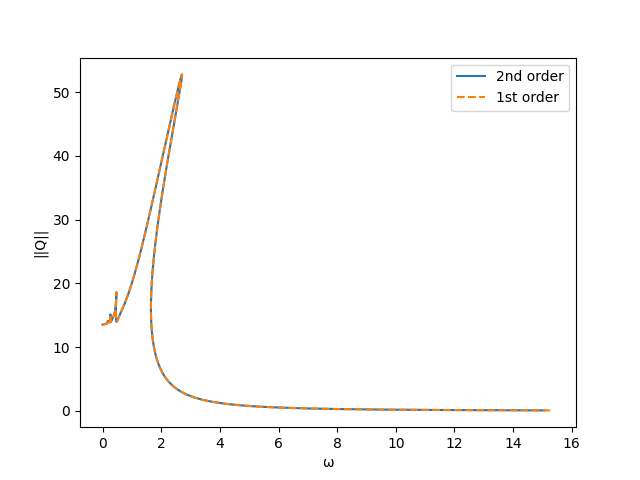

---
## 6 · Summary

<table style="width:100%; border-collapse:collapse; font-size:0.93em;">
  <thead>
    <tr style="background:#16213e;">
      <th style="padding:10px; color:#e0e0e0; border-bottom:2px solid #4fc3f7; text-align:left;">File</th>
      <th style="padding:10px; color:#e0e0e0; border-bottom:2px solid #4fc3f7; text-align:left;">Change</th>
      <th style="padding:10px; color:#e0e0e0; border-bottom:2px solid #4fc3f7; text-align:left;">Reason</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background:#0d1117;">
      <td style="padding:9px; color:#4fc3f7;"><code>dynamical_system.py</code></td>
      <td style="padding:9px; color:#ccc;">New <code>SecondOrderODE</code> base class</td>
      <td style="padding:9px; color:#aaa;">Interface for <b>M</b>, <b>C</b>, <b>K</b> and $\partial f^\mathrm{nl}/\partial\dot{\mathbf{q}}$</td>
    </tr>
    <tr style="background:#161b22;">
      <td style="padding:9px; color:#4fc3f7;"><code>frequency_domain.py</code></td>
      <td style="padding:9px; color:#ccc;">New <code>FrequencyDomainSecondOrderODE_Real</code></td>
      <td style="padding:9px; color:#aaa;">Re-derived residue, Jacobian and $dR/d\omega$ for 2nd order</td>
    </tr>
    <tr style="background:#0d1117;">
      <td style="padding:9px; color:#4fc3f7;"><code>core.py</code></td>
      <td style="padding:9px; color:#ccc;">Added <code>second_order_ode</code> parameter + fixed 2 call sites</td>
      <td style="padding:9px; color:#aaa;">Route to correct class; pass full <code>FourierOmegaPoint</code> for $\omega$ access</td>
    </tr>
  </tbody>
</table>

<div style="background: linear-gradient(135deg, #1a1a2e, #0f3460); padding: 20px 25px; border-radius: 10px; margin-top: 20px; border: 1px solid #e94560;">
  <b style="color:#e94560; font-size:1.1em;">Result</b><br><br>
  <span style="color:#a8b2d8;">The 2nd order formulation solves a system <b>half the size</b> and operates directly on physical matrices <b>M</b>, <b>C</b>, <b>K</b>. The FRCs of both formulations match exactly — confirming correctness.</span>
</div>